In [51]:
import numpy as np
import math
from sympy import *
import matplotlib.pyplot as plt

In [44]:
#A = [1,2,3,4]
#B = [3,5,6,8]
#A = [0,1,2,3,4,5,6]
#B = [32,47,65,92,132,190,275]
A = [-3,-2,-1,0,1,2,3,4,5,6]
B = [24.8,13.23,4.99,0.85,1.42,6.02,14.78,27.02,45.44,65.82]

In [5]:
def metMMQLinear(vet_x, fx_y):
  
  #somatorios
  sumXY=0; sumX=0; sumY=0; sumX2=0
  for i in range(len(vet_x)):
    sumXY = sumXY + vet_x[i] * fx_y[i]
    sumX = sumX + vet_x[i]
    sumY = sumY + fx_y[i] 
    sumX2 = sumX2 + math.pow(vet_x[i],2)

  a = ((len(vet_x)*sumXY)-sumX*sumY)/(len(vet_x)*sumX2 - math.pow(sumX,2))
  b = ((sumX*sumXY) - sumY*sumX2)/(math.pow(sumX,2) - len(vet_x)*sumX2)

  f_x = lambda x: a*x +b
  return f_x

In [22]:
def metMMQAXB(vet_x,fx_y):
  sumXY=0; sumX=0; sumY=0; sumX2=0
  for i in range(len(vet_x)):
    sumXY = sumXY + np.log(vet_x[i]) * np.log(fx_y[i])
    sumX = sumX + np.log(vet_x[i])
    sumY = sumY + np.log(fx_y[i])
    sumX2 = sumX2 + math.pow(np.log(vet_x[i]),2)

  b = ((len(vet_x)*sumXY)-sumX*sumY)/(len(vet_x)*sumX2 - math.pow(sumX,2))
  a = ((sumX*sumXY) - sumY*sumX2)/(math.pow(sumX,2) - len(vet_x)*sumX2)

  a = np.exp(a)

  f_x = lambda x: a * x**b

  return a,b

In [21]:
def metMMQABX(vet_x,fx_y):
  sumXY=0; sumX=0; sumY=0; sumX2=0
  for i in range(len(vet_x)):
    sumXY = sumXY + np.log(vet_x[i]) * np.log(fx_y[i])
    sumX = sumX + np.log(vet_x[i])
    sumY = sumY + np.log(fx_y[i])
    sumX2 = sumX2 + math.pow(np.log(vet_x[i]),2)


  b = ((len(vet_x)*sumXY)-sumX*sumY)/(len(vet_x)*sumX2 - math.pow(sumX,2))
  a = ((sumX*sumXY) - sumY*sumX2)/(math.pow(sumX,2) - len(vet_x)*sumX2)

  a = np.exp(a)
  b = np.exp(b)

  f_x = lambda x: a * b**x

  return a,b

In [56]:
def metMMQX2(vet_x,fx_y):
  sumXY=0; sumX=0; sumY=0; sumX2=0; sumX3=0;sumX4=0;sumX2Y=0
  for i in range(len(vet_x)):
    sumXY = sumXY + vet_x[i] * fx_y[i]
    sumX = sumX + vet_x[i]
    sumY = sumY + fx_y[i] 
    sumX2 = sumX2 + math.pow(vet_x[i],2)
    sumX3 = sumX3 + math.pow(vet_x[i],3)
    sumX4 = sumX4 + math.pow(vet_x[i],4)
    sumX2Y = sumX2Y + math.pow(vet_x[i],2)*fx_y[i]

  vet = np.zeros((3, 3))
  vety = np.zeros(3)

  vet[0,0] = len(vet_x)
  vet[0,1] = sumX
  vet[0,2] = sumX2
  vet[1,0] = sumX
  vet[1,1] = sumX2
  vet[1,2] = sumX3
  vet[2,0] = sumX2
  vet[2,1] = sumX3
  vet[2,2] = sumX4
  vety[0] = sumY
  vety[1] = sumXY
  vety[2] = sumX2Y
  
  n = np.linalg.solve(vet,vety)
  f_x = lambda x: n[2]*x**2 + n[1]*x + n[0]

  print(n)
  return f_x

In [16]:
metMMQLinear(A,B)

In [20]:
metMMQAXB(A,B)


(1.977849991352402, 1.1029463685216792)

[ 1.05345455 -1.72460606  2.09242424]


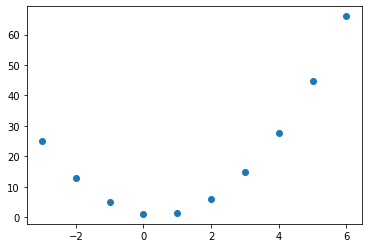

In [57]:
f_X = metMMQX2(A,B)

AX2 = np.zeros(len(A))

for i in range(len(A)):
  AX2[i] = f_X(A[i])

plt.scatter(A, AX2)
plt.show()